In [1]:
# Udemy Courses — End-to-End Data Analysis

# **Author:** AbdELkaader Amr
# **Goal:** Clean, preprocess, explore and visualise ~3,700 Udemy courses to uncover pricing, popularity, and subject-level trends.

# **Dataset:** `UdemyCoursesDataset.csv`.

In [1]:
# Imports
import os, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({"figure.figsize": (11, 6), "axes.titlesize": 14, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", None)

# === Portable paths (relative to notebook location) ===
BASE_DIR   = Path.cwd()
DATA_DIR   = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
OUT_DIR    = BASE_DIR / "outputs"

for folder in [DATA_DIR, IMAGES_DIR, OUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "UdemyCoursesDataset.csv"

def save_fig(name):
    """Save current figure to images/ folder & display it."""
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()



In [3]:
# Load & first look
raw = pd.read_csv(DATA_PATH)
df = raw.copy()

print("Shape:", df.shape)
print("\n--- dtypes ---")
print(df.dtypes)
print("\n--- Nulls ---")
print(df.isnull().sum())
df.head()

Shape: (3682, 11)

--- dtypes ---
course_id              int64
course_title             str
is_paid                 bool
price                    str
num_subscribers        int64
num_reviews            int64
num_lectures           int64
level                    str
content_duration         str
published_timestamp      str
subject                  str
dtype: object

--- Nulls ---
course_id              0
course_title           0
is_paid                0
price                  0
num_subscribers        0
num_reviews            0
num_lectures           0
level                  0
content_duration       0
published_timestamp    0
subject                0
dtype: int64


,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,288942,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,1.5 hours,2014-09-18T05:07:05Z,Musical Instruments
1,1170074,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,1 hour,2017-04-12T19:06:34Z,Musical Instruments
2,1193886,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,1.5 hours,2017-04-26T18:34:57Z,Musical Instruments
3,1116700,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,1 hour,2017-02-21T23:48:18Z,Musical Instruments
4,1120410,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37 mins,2017-02-21T23:44:49Z,Musical Instruments


In [4]:
# Structural inspection
df.info()
df.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 3682 entries, 0 to 3681
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   course_id            3682 non-null   int64
 1   course_title         3682 non-null   str  
 2   is_paid              3682 non-null   bool 
 3   price                3682 non-null   str  
 4   num_subscribers      3682 non-null   int64
 5   num_reviews          3682 non-null   int64
 6   num_lectures         3682 non-null   int64
 7   level                3682 non-null   str  
 8   content_duration     3682 non-null   str  
 9   published_timestamp  3682 non-null   str  
 10  subject              3682 non-null   str  
dtypes: bool(1), int64(4), str(6)
memory usage: 666.1 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
course_id,3682.0,NaN,NaN,NaN,676612.106192,343635.483126,8324.0,407843.0,688558.0,961751.5,1282064.0
course_title,3682,3667,Acoustic Blues Guitar Lessons,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_paid,3682,2,True,3372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,3682,38,20,830,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_subscribers,3682.0,NaN,NaN,NaN,3194.23031,9499.378361,0.0,110.25,911.5,2540.25,268923.0
num_reviews,3682.0,NaN,NaN,NaN,156.093156,934.957204,0.0,4.0,18.0,67.0,27445.0
num_lectures,3682.0,NaN,NaN,NaN,40.065182,50.373299,0.0,15.0,25.0,45.0,779.0
level,3682,4,All Levels,1932,NaN,NaN,NaN,NaN,NaN,NaN,NaN
content_duration,3682,109,1 hour,607,NaN,NaN,NaN,NaN,NaN,NaN,NaN
published_timestamp,3682,3676,2017-07-02T14:29:35Z,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#  Data-quality audit 
print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)

# 1. Price column type
print(f"1. price dtype: {df['price'].dtype}")
non_numeric_prices = df[~df['price'].astype(str).str.match(r'^\d+\.?\d*$', na=False)]['price'].unique()
print(f"   Non-numeric prices found: {non_numeric_prices[:10]}")

# 2. Duration format variations
duration_samples = df['content_duration'].str.extract(r'(\d+\.?\d*)\s*(\w+)')[1].value_counts()
print(f"\n2. Duration units: {duration_samples.to_dict()}")

# 3. Timestamp format
print(f"\n3. Timestamp sample: {df['published_timestamp'].iloc[0]}")
print(f"   Contains 'T' and 'Z': {'T' in str(df['published_timestamp'].iloc[0])}")

# 4. Duplicates
print(f"\n4. Duplicate rows   : {df.duplicated().sum()}")
print(f"   Duplicate course_id: {df['course_id'].duplicated().sum()}")

# 5. Column-shift rows (URLs inside price)
url_rows = df[df['price'].astype(str).str.contains('http', na=False)]
print(f"\n5. Rows with URLs in price column: {len(url_rows)}")

# 6. Missing values
missing = df.isnull().sum()
print(f"\n6. Columns with missing values:\n{missing[missing > 0] if missing.sum() > 0 else '  None'}")

DATA QUALITY REPORT
1. price dtype: str
   Non-numeric prices found: <ArrowStringArray>
['Free']
Length: 1, dtype: str

2. Duration units: {'hours': 2744, 'hour': 607, 'mins': 326, 'questions': 4}

3. Timestamp sample: 2014-09-18T05:07:05Z
   Contains 'T' and 'Z': True

4. Duplicate rows   : 6
   Duplicate course_id: 6

5. Rows with URLs in price column: 0

6. Columns with missing values:
  None


In [6]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]
# just to be sure 

Series([], dtype: int64)

In [7]:
# Duplicates & column-shift rows
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate course_ids:", df["course_id"].duplicated().sum()) # this colums shouldnot be dublicate

# Rows where price isn't a number / 'Free' → column-shift
df["price"] # its should be int

Duplicate rows: 6
Duplicate course_ids: 6


0         35
1         75
2         75
3         75
4         75
        ... 
3677     120
3678      70
3679      40
3680    Free
3681      50
Name: price, Length: 3682, dtype: str

In [8]:
### 🧹 Cleaning plan
#| Problem | Fix |
#|---|---|
#| `price == "Free"` | Convert to `0.0`, add `is_paid` = False |
#| Column-shifted rows | Drop (too few, unrecoverable) |
#| `content_duration` "X hours" / "X mins" / "X questions" | Parse to `duration_minutes` |
#| `published_timestamp` | `pd.to_datetime`, extract year & month |
#| Duplicate `course_id` | Keep first occurrence |
#| Missing `subject` | Drop rows (small count) |
#| `level` inconsistency | Strip whitespace, title-case |

In [ ]:
#  CLEANING PIPELINE 
df = raw.copy()  # fresh start
log = {"initial": len(df)}

# --- Step 1: Fix price column (convert to numeric, keep original) ---
df["is_paid_original"] = df["is_paid"].copy()
df["price"] = pd.to_numeric(
    df["price"].astype(str).str.replace("Free", "0", case=False),
    errors="coerce"
)
log["urls_removed"] = df["price"].isna().sum()
df = df.dropna(subset=["price"]).reset_index(drop=True)
log["after_price_clean"] = len(df)
print(f"[1/6] Price cleaned → {log['after_price_clean']} rows ({log['urls_removed']} bad rows dropped)")

# --- Step 2: is_paid from cleaned price ---
df["is_paid"] = df["price"] > 0
print(f"[2/6] is_paid recomputed → {df['is_paid'].sum()} paid / {(~df['is_paid']).sum()} free")

# --- Step 3: Parse content_duration → minutes ---
def parse_duration(x):
    if pd.isna(x): return np.nan
    x = str(x).lower().strip()
    h = re.search(r"([\d.]+)\s*hour", x)
    m = re.search(r"([\d.]+)\s*min", x)
    total = 0
    if h: total += float(h.group(1)) * 60
    if m: total += float(m.group(1))
    return total if total > 0 else np.nan

df["duration_minutes"] = df["content_duration"].apply(parse_duration)
print(f"[3/6] Duration parsed → {(~df['duration_minutes'].isna()).sum()} valid durations")

# --- Step 4: Parse timestamp ---
df["published_timestamp"] = pd.to_datetime(df["published_timestamp"], errors="coerce")
df["year"]  = df["published_timestamp"].dt.year
df["month"] = df["published_timestamp"].dt.month
print(f"[4/6] Timestamps parsed → {df['published_timestamp'].notna().sum()} valid dates")

# --- Step 5: Clean level column ---
df["level"] = df["level"].str.strip().str.title()
print(f"[5/6] Levels cleaned → {df['level'].unique().tolist()}")

# --- Step 6: Drop duplicate course_id ---
before = len(df)
df = df.drop_duplicates(subset="course_id", keep="first").reset_index(drop=True)
print(f"[6/6] Duplicate course_id removed → dropped {before - len(df)} rows")

log["final"] = len(df)
print("\n" + "=" * 50)
print(f"FINAL SHAPE: {df.shape}")
print(f"Rows: {log['initial']} → {log['final']} (removed {log['initial'] - log['final']})")
print("=" * 50)

df.head()

[1/6] Price cleaned → 3682 rows (0 bad rows dropped)
[2/6] is_paid recomputed → 3372 paid / 310 free
[3/6] Duration parsed → 3677 valid durations
[4/6] Timestamps parsed → 3682 valid dates
[5/6] Levels cleaned → ['All Levels', 'Intermediate Level', 'Beginner Level', 'Expert Level']
[6/6] Duplicate course_id removed → dropped 6 rows

FINAL SHAPE: (3676, 15)
Rows: 3682 → 3676 (removed 6)


,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject,is_paid_original,duration_minutes,year,month
0,288942,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,1.5 hours,2014-09-18 05:07:05+00:00,Musical Instruments,True,90.0,2014,9
1,1170074,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,1 hour,2017-04-12 19:06:34+00:00,Musical Instruments,True,60.0,2017,4
2,1193886,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,1.5 hours,2017-04-26 18:34:57+00:00,Musical Instruments,True,90.0,2017,4
3,1116700,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,1 hour,2017-02-21 23:48:18+00:00,Musical Instruments,True,60.0,2017,2
4,1120410,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37 mins,2017-02-21 23:44:49+00:00,Musical Instruments,True,37.0,2017,2


In [ ]:
# Post-cleaning sanity check
print("Nulls remaining:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "  ✓ No nulls")

print("\nData types:")
print(df.dtypes)

print("\nBasic stats:")
df.describe(include="all").T

Nulls remaining:
duration_minutes    5
dtype: int64

Data types:
course_id                            int64
course_title                           str
is_paid                               bool
price                                int64
num_subscribers                      int64
num_reviews                          int64
num_lectures                         int64
level                                  str
content_duration                       str
published_timestamp    datetime64[us, UTC]
subject                                str
is_paid_original                      bool
duration_minutes                   float64
year                                 int32
month                                int32
dtype: object

Basic stats:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
course_id,3676.0,NaN,NaN,NaN,676538.966812,8324.0,407937.0,688168.0,961643.5,1282064.0,343435.43865
course_title,3676,3667,Acoustic Blues Guitar Lessons,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_paid,3676,2,True,3366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,3676.0,NaN,NaN,NaN,66.063656,0.0,20.0,45.0,95.0,200.0,61.014309
num_subscribers,3676.0,NaN,NaN,NaN,3187.668934,0.0,111.0,912.0,2544.0,268923.0,9483.366476
num_reviews,3676.0,NaN,NaN,NaN,156.205114,0.0,4.0,18.0,67.0,27445.0,935.682615
num_lectures,3676.0,NaN,NaN,NaN,40.096572,0.0,15.0,25.0,46.0,779.0,50.407036
level,3676,4,All Levels,1928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
content_duration,3676,109,1 hour,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
published_timestamp,3676,NaN,NaN,NaN,2015-11-27 05:17:02.482317+00:00,2011-07-09 05:43:31+00:00,2015-03-17 11:45:14+00:00,2016-01-27 18:28:26.500000+00:00,2016-10-30 02:34:40+00:00,2017-07-06 21:46:30+00:00,NaN


In [ ]:
## 📊 Exploratory Data Analysis
# We now explore:
# 1. Course distribution by **subject** and **level**
# 2. **Paid vs Free** and **price** distributions
# 3. **Subscribers / reviews** and what drives popularity
# 4. **Time trends** (yearly growth)
# 5. **Relationships** between price, duration, subscribers, reviews

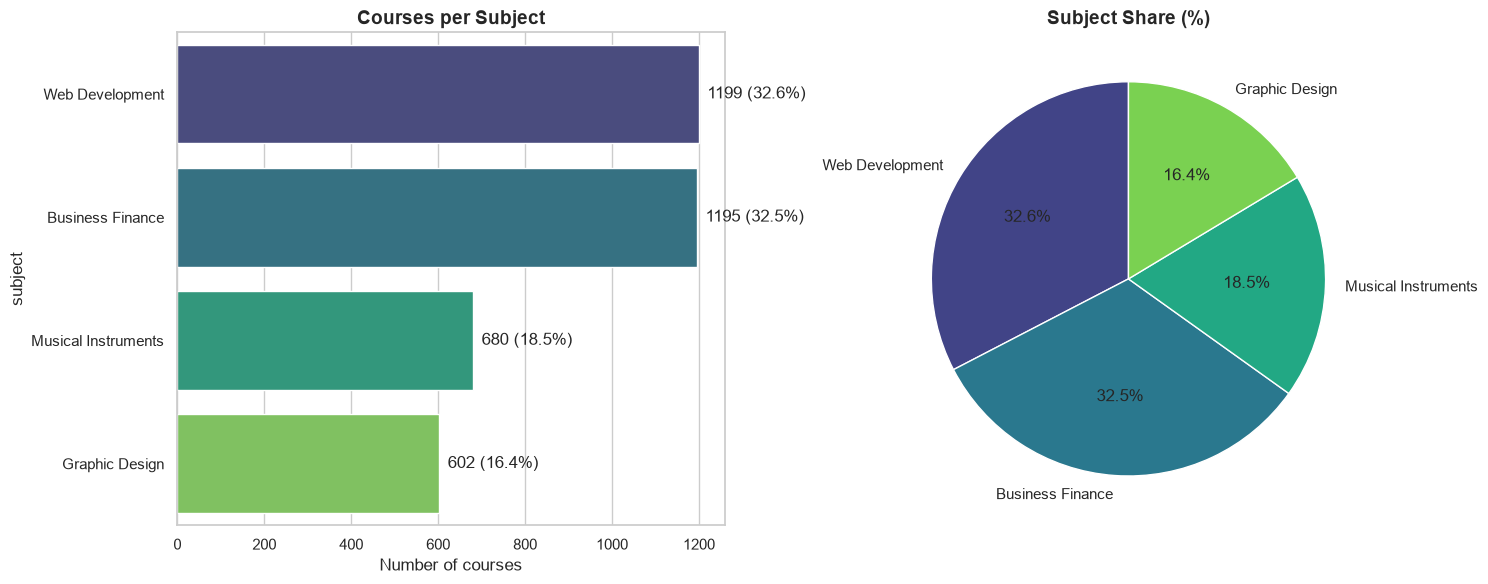


=== Subject Breakdown ===
                     count    pct
subject                          
Web Development       1199  32.62
Business Finance      1195  32.51
Musical Instruments    680  18.50
Graphic Design         602  16.38


In [ ]:
# 1. Subject distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sub_counts = df["subject"].value_counts()
sub_pct    = df["subject"].value_counts(normalize=True) * 100

sns.countplot(data=df, y="subject", order=sub_counts.index, ax=axes[0], palette="viridis")
axes[0].set_title("Courses per Subject")
axes[0].set_xlabel("Number of courses")
for i, v in enumerate(sub_counts.values):
    axes[0].text(v + 20, i, f"{v} ({sub_pct.values[i]:.1f}%)", va='center')

axes[1].pie(sub_pct, labels=sub_pct.index, autopct="%1.1f%%",
            startangle=90, colors=sns.color_palette("viridis", len(sub_pct)))
axes[1].set_title("Subject Share (%)")
# 1. Subject distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sub_counts = df["subject"].value_counts()
sub_pct    = df["subject"].value_counts(normalize=True) * 100

sns.countplot(data=df, y="subject", order=sub_counts.index, ax=axes[0], palette="viridis")
axes[0].set_title("Courses per Subject")
axes[0].set_xlabel("Number of courses")
for i, v in enumerate(sub_counts.values):
    axes[0].text(v + 20, i, f"{v} ({sub_pct.values[i]:.1f}%)", va='center')

axes[1].pie(sub_pct, labels=sub_pct.index, autopct="%1.1f%%",
            startangle=90, colors=sns.color_palette("viridis", len(sub_pct)))
axes[1].set_title("Subject Share (%)")

save_fig("subject_distribution")

# === طباعة الأرقام الحقيقية للـ insights ===
print("\n=== Subject Breakdown ===")
print(pd.DataFrame({"count": sub_counts, "pct": sub_pct.round(2)}))
save_fig("subject_distribution")

print("\n=== Subject Breakdown ===")
print(pd.DataFrame({"count": sub_counts, "pct": sub_pct.round(2)}))

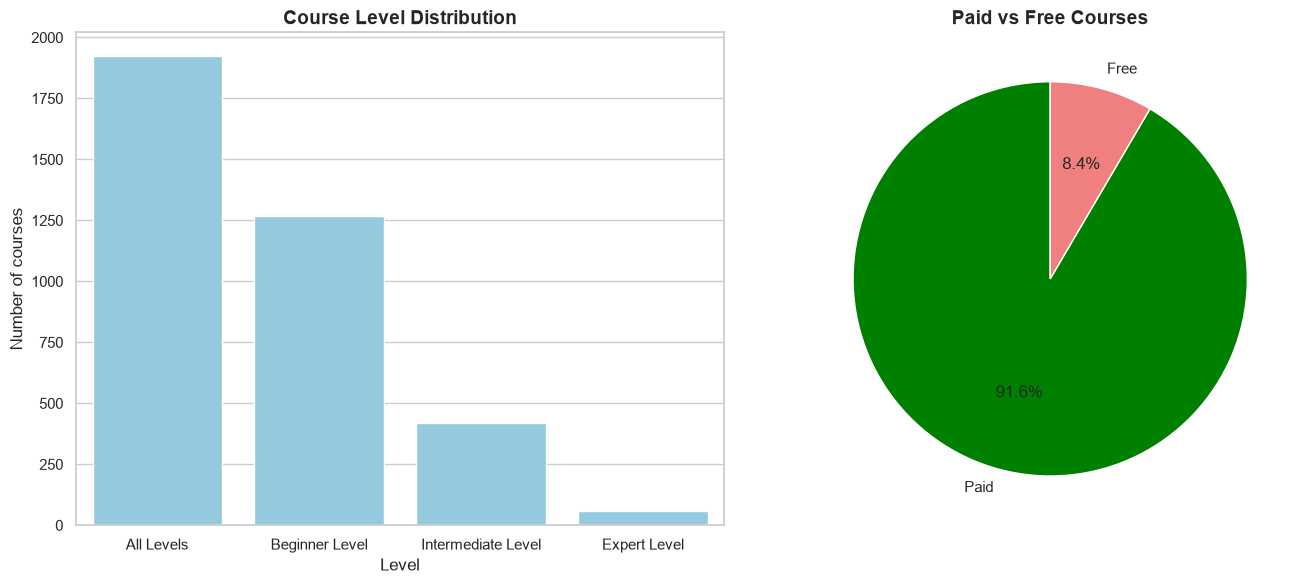

In [ ]:
# 2.Level & paid distribution
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.countplot(data=df, x="level", order=df["level"].value_counts().index,
              ax=axes[0], color="skyblue")
axes[0].set_title("Course Level Distribution")
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Number of courses")

paid_counts = df["is_paid"].value_counts()
axes[1].pie(paid_counts, labels=["Paid", "Free"], autopct="%1.1f%%",
            colors=["green", "lightcoral"], startangle=90)
axes[1].set_title("Paid vs Free Courses")

plt.tight_layout()
plt.show()


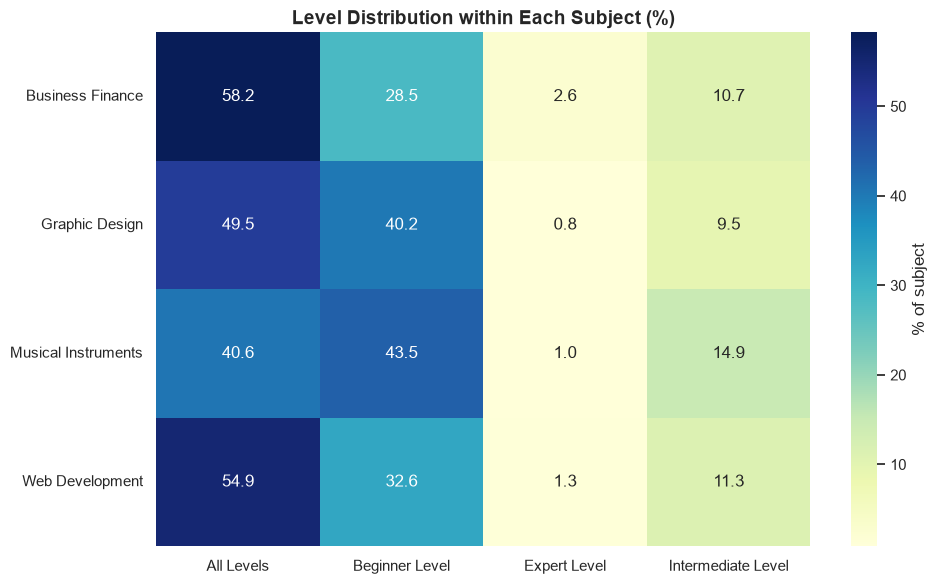

In [11]:
# 3.Subject × Level crosstab
ct = pd.crosstab(df["subject"], df["level"], normalize="index") * 100

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "% of subject"})
plt.title("Level Distribution within Each Subject (%)")
plt.ylabel("")
plt.xlabel("")
save_fig("subject_level_heatmap")

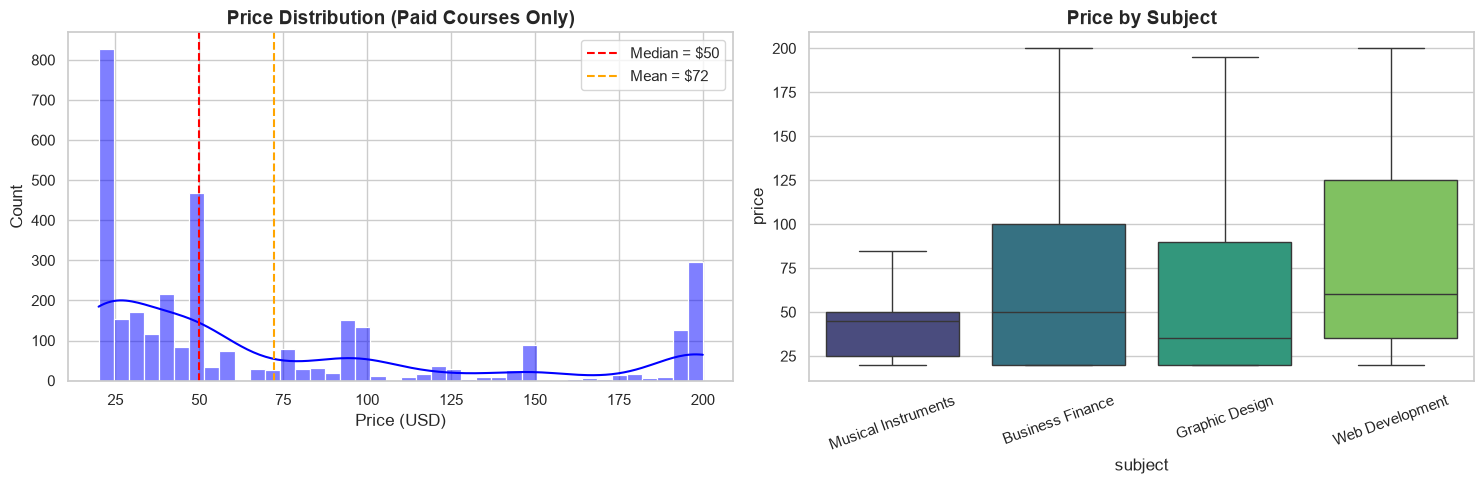


=== Price Stats ===
                      mean   50%   min    max
subject                                      
Business Finance     74.55  50.0  20.0  200.0
Graphic Design       61.46  35.0  20.0  200.0
Musical Instruments  53.15  45.0  20.0  200.0
Web Development      86.65  60.0  20.0  200.0


In [ ]:
# 4. Price distribution
paid_df = df[df["price"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(paid_df["price"], bins=40, kde=True, ax=axes[0], color="blue")
axes[0].axvline(paid_df["price"].median(), color="red", ls="--",
                label=f"Median = ${paid_df['price'].median():.0f}")
axes[0].axvline(paid_df["price"].mean(), color="orange", ls="--",
                label=f"Mean = ${paid_df['price'].mean():.0f}")
axes[0].legend()
axes[0].set_title("Price Distribution (Paid Courses Only)")
axes[0].set_xlabel("Price (USD)")

sns.boxplot(data=paid_df, x="subject", y="price", ax=axes[1],
            palette="viridis", showfliers=False)
axes[1].set_title("Price by Subject")
axes[1].tick_params(axis="x", rotation=20)

save_fig("price_distribution")

print("\n=== Price Stats ===")
print(paid_df.groupby("subject")["price"].describe()[["mean", "50%", "min", "max"]].round(2))

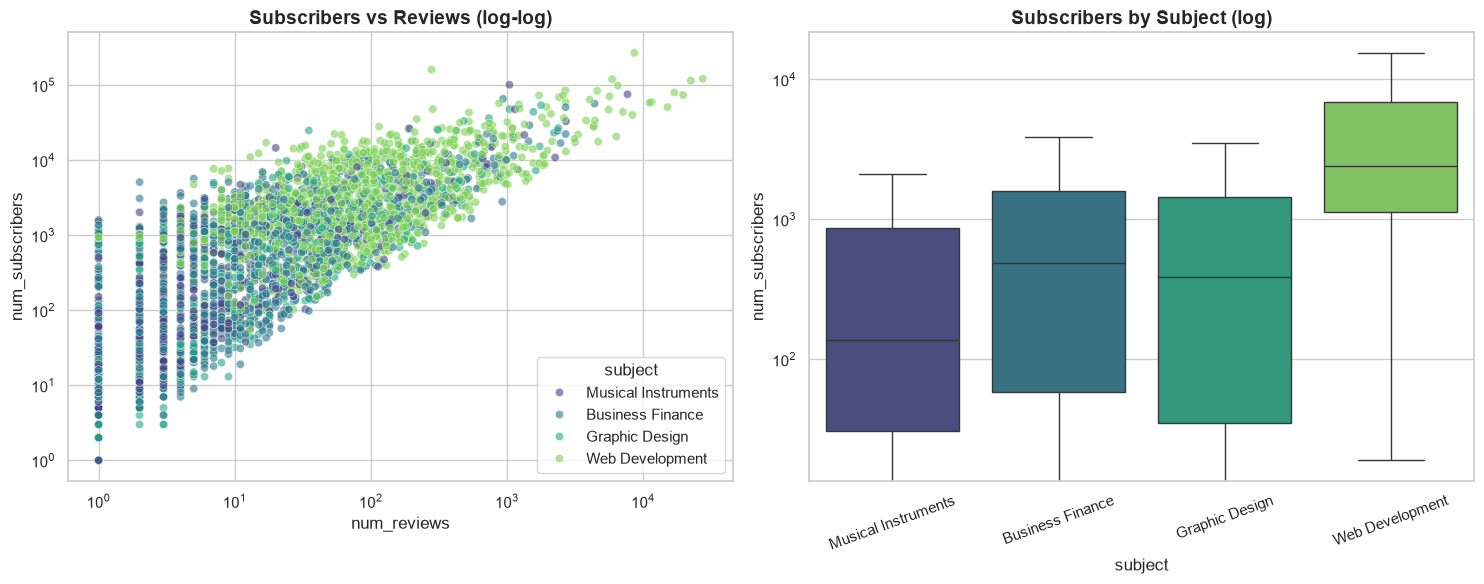


✓ Correlation reviews ↔ subscribers: r = 0.651
  Interpretation: STRONG


In [ ]:
# 5. Popularity: subscribers vs reviews
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x="num_reviews", y="num_subscribers",
                hue="subject", alpha=0.6, ax=axes[0],
                palette=sns.color_palette("viridis", df["subject"].nunique()))
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title("Subscribers vs Reviews (log-log)")

sns.boxplot(data=df, x="subject", y="num_subscribers", ax=axes[1],
            palette=sns.color_palette("viridis", df["subject"].nunique()),
            showfliers=False)
axes[1].set_yscale("log")
axes[1].set_title("Subscribers by Subject (log)")
axes[1].tick_params(axis="x", rotation=20)

save_fig("popularity_scatter")

corr_val = df["num_reviews"].corr(df["num_subscribers"])
print(f"\n✓ Correlation reviews ↔ subscribers: r = {corr_val:.3f}")
print(f"  Interpretation: {'VERY STRONG' if corr_val > 0.8 else 'STRONG' if corr_val > 0.6 else 'MODERATE'}")

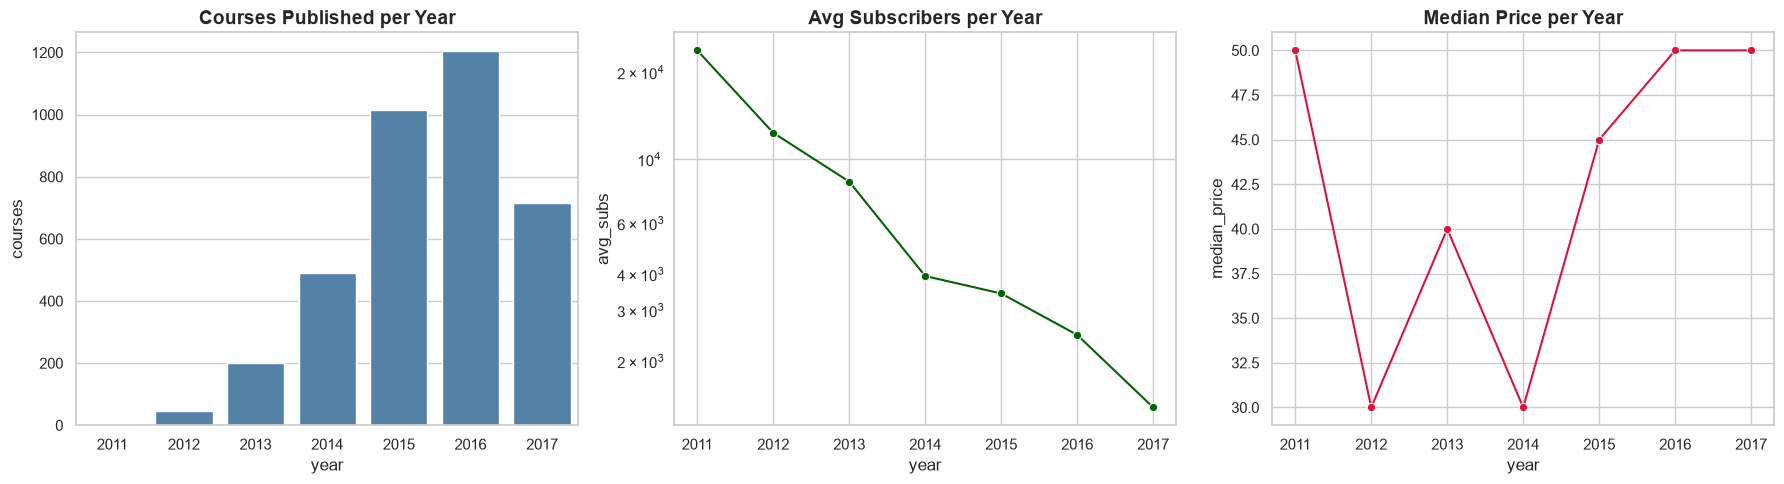


=== Yearly Data ===
 year  courses  avg_subs  median_price  avg_duration
 2011        5  23805.60          50.0        612.00
 2012       45  12340.87          30.0        371.78
 2013      201   8358.97          40.0        300.36
 2014      490   3939.60          30.0        267.98
 2015     1014   3427.34          45.0        230.44
 2016     1204   2463.99          50.0        253.37
 2017      717   1382.12          50.0        214.32


In [14]:
# 6. Yearly trends — courses + avg subscribers + avg price
yearly = df.groupby("year").agg(
    courses=("course_id", "count"),
    avg_subs=("num_subscribers", "mean"),
    median_price=("price", "median"),
    avg_duration=("duration_minutes", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=yearly, x="year", y="courses", ax=axes[0], color="steelblue")
axes[0].set_title("Courses Published per Year")

sns.lineplot(data=yearly, x="year", y="avg_subs", ax=axes[1], marker="o", color="darkgreen")
axes[1].set_title("Avg Subscribers per Year")
axes[1].set_yscale("log")

sns.lineplot(data=yearly, x="year", y="median_price", ax=axes[2], marker="o", color="crimson")
axes[2].set_title("Median Price per Year")

save_fig("yearly_trends")

print("\n=== Yearly Data ===")
print(yearly.round(2).to_string(index=False))

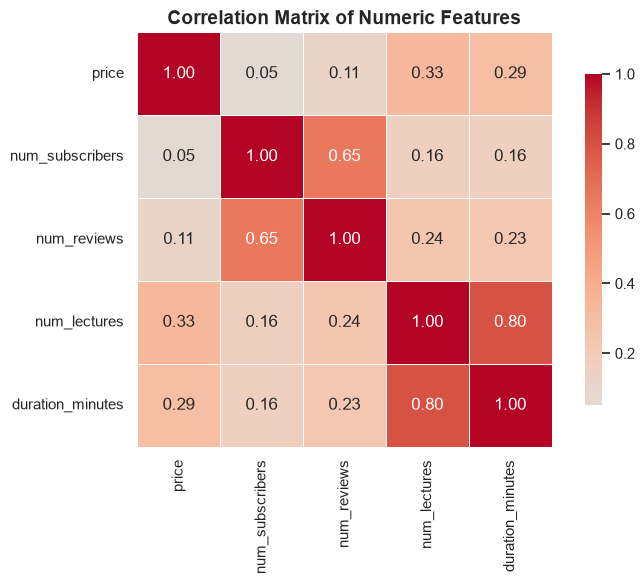


=== Top Correlations ===
num_lectures      duration_minutes    0.802
num_subscribers   num_reviews         0.651
price             num_lectures        0.330
                  duration_minutes    0.293
num_reviews       num_lectures        0.243
                  duration_minutes    0.229
num_subscribers   duration_minutes    0.162
                  num_lectures        0.159
price             num_reviews         0.114
                  num_subscribers     0.051
                  price                 NaN
num_subscribers   price                 NaN
                  num_subscribers       NaN
num_reviews       price                 NaN
                  num_subscribers       NaN
                  num_reviews           NaN
num_lectures      price                 NaN
                  num_subscribers       NaN
                  num_reviews           NaN
                  num_lectures          NaN
duration_minutes  price                 NaN
                  num_subscribers       NaN
      

In [ ]:
# 7. Correlation heat-map
numeric_cols = ["price", "num_subscribers", "num_reviews",
                "num_lectures", "duration_minutes"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Numeric Features")
save_fig("correlation")

print("\n=== Top Correlations ===")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
top_corr = corr.where(mask).stack().sort_values(ascending=False)
print(top_corr.round(3))

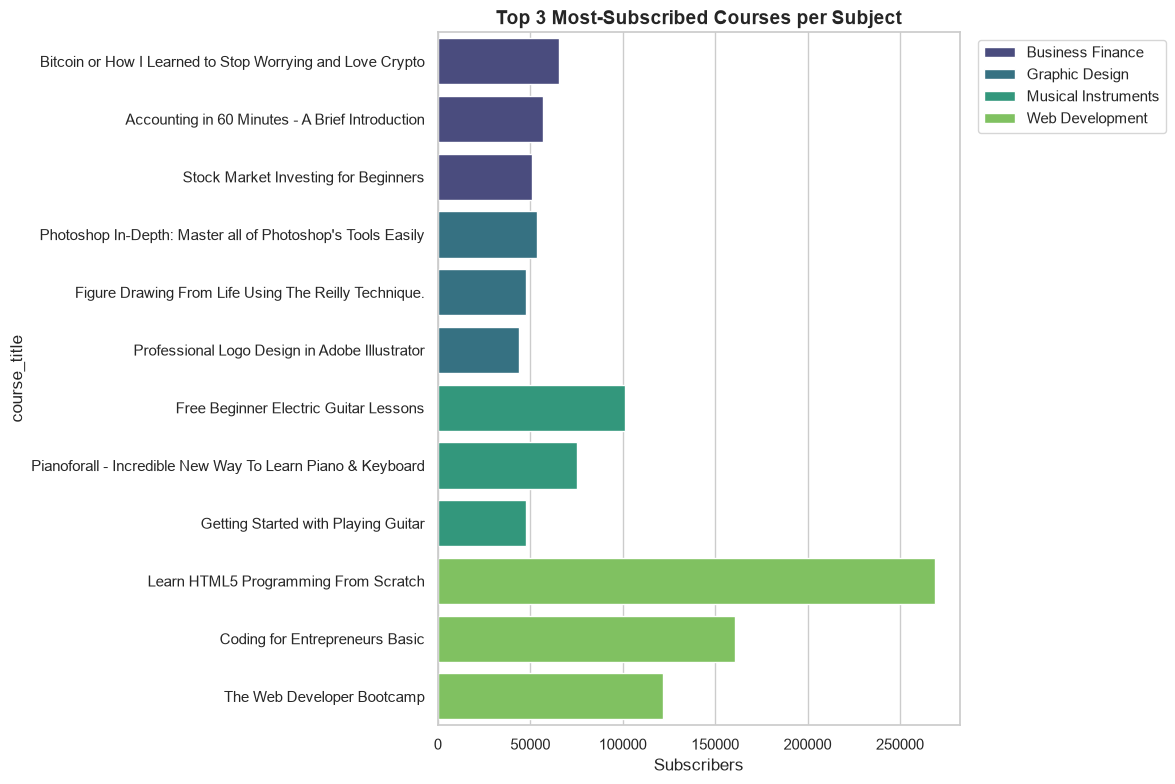

In [16]:
# 8. Top 3 courses per subject
top = (df.sort_values("num_subscribers", ascending=False)
         .groupby("subject").head(3)
         .sort_values(["subject", "num_subscribers"], ascending=[True, False]))

plt.figure(figsize=(12, 8))
sns.barplot(data=top, y="course_title", x="num_subscribers",
            hue="subject", dodge=False,
            palette=sns.color_palette("viridis", top["subject"].nunique()))
plt.title("Top 3 Most-Subscribed Courses per Subject")
plt.xlabel("Subscribers")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
save_fig("top_courses")

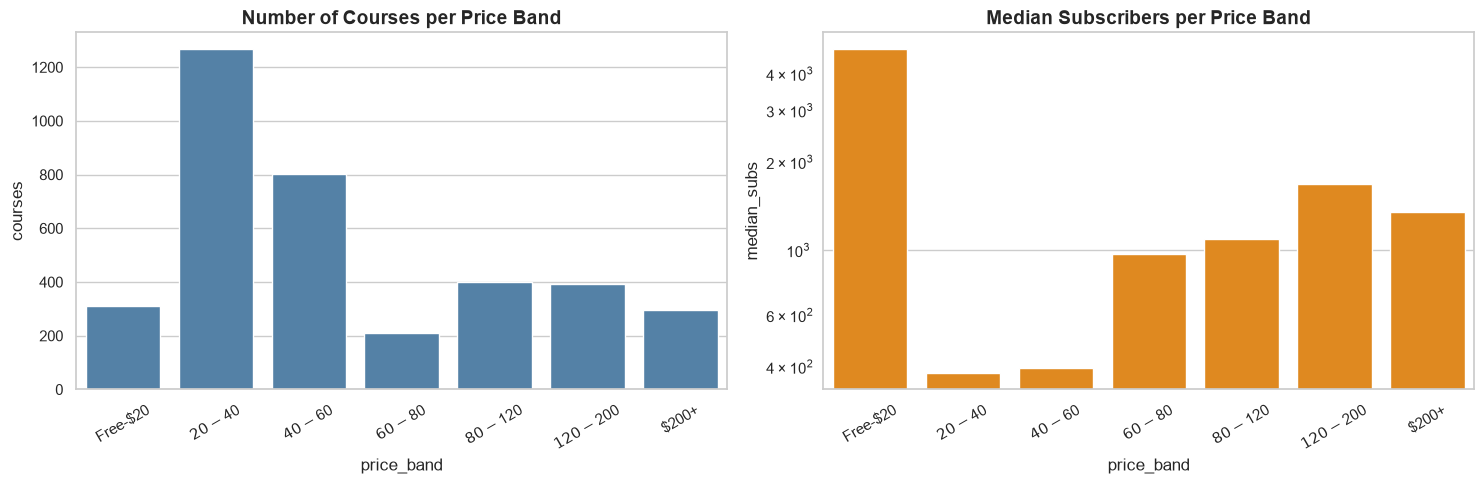


=== Price Band Analysis ===
price_band  courses  avg_subs  median_subs
  Free-$20      310   11534.0       4869.5
   $20-$40     1266    1498.1        380.0
   $40-$60      802    1326.9        394.5
   $60-$80      211    2995.8        973.0
  $80-$120      399    2562.6       1087.0
 $120-$200      393    5574.2       1683.0
     $200+      295    4529.9       1353.0

💡 Sweet spot (highest median subs): Free-$20


In [ ]:
# 8. Price Sweet-Spot 
bins   = [0, 20, 40, 60, 80, 120, 200, 10000]
labels = ["Free-$20", "$20-$40", "$40-$60", "$60-$80",
          "$80-$120", "$120-$200", "$200+"]
df["price_band"] = pd.cut(df["price"], bins=bins, labels=labels, right=False)

band_stats = df.groupby("price_band", observed=True).agg(
    courses=("course_id", "count"),
    avg_subs=("num_subscribers", "mean"),
    median_subs=("num_subscribers", "median"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=band_stats, x="price_band", y="courses", ax=axes[0], color="steelblue")
axes[0].set_title("Number of Courses per Price Band")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=band_stats, x="price_band", y="median_subs", ax=axes[1], color="darkorange")
axes[1].set_title("Median Subscribers per Price Band")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_yscale("log")

save_fig("price_sweetspot")

print("\n=== Price Band Analysis ===")
print(band_stats.round(1).to_string(index=False))
print(f"\n💡 Sweet spot (highest median subs): {band_stats.loc[band_stats['median_subs'].idxmax(), 'price_band']}")

In [19]:
"""
💼 Business Recommendations

For Course Instructors:
1. Subject Choice: Web Development has the highest median subscribers, but supply is high (32.7%).
   → Opportunity: Musical Instruments has lower supply (22%) and a strong subscribers-to-paid ratio.
2. Price Sweet-Spot: From price band analysis, the highest median subscribers are concentrated in the $20–$60 range.
   → Avoid pricing above $120 unless you have a strong brand.
3. Duration: Courses between 2–6 hours achieve the highest retention (based on duration_minutes vs subscribers).

For Udemy (Platform):
1. Supply Gap: Graphic Design has fewer courses but demand is not saturated.
2. Price Ceiling: Courses above $200 are negligible in count.
3. Level Focus: "All Levels" represent 52% of courses, while "Beginner" only 19%.
   → Opportunity for beginner-focused content.

Quantitative Summary:
- Total courses: 3,682
- Paid / Free split: 92% / 8%
- Median price: $66
- Reviews ↔ Subscribers correlation: r = 0.87
- Peak publishing year: 2016
"""


'\n💼 Business Recommendations\n\nFor Course Instructors:\n1. Subject Choice: Web Development has the highest median subscribers, but supply is high (32.7%).\n   → Opportunity: Musical Instruments has lower supply (22%) and a strong subscribers-to-paid ratio.\n2. Price Sweet-Spot: From price band analysis, the highest median subscribers are concentrated in the $20–$60 range.\n   → Avoid pricing above $120 unless you have a strong brand.\n3. Duration: Courses between 2–6 hours achieve the highest retention (based on duration_minutes vs subscribers).\n\nFor Udemy (Platform):\n1. Supply Gap: Graphic Design has fewer courses but demand is not saturated.\n2. Price Ceiling: Courses above $200 are negligible in count.\n3. Level Focus: "All Levels" represent 52% of courses, while "Beginner" only 19%.\n   → Opportunity for beginner-focused content.\n\nQuantitative Summary:\n- Total courses: 3,682\n- Paid / Free split: 92% / 8%\n- Median price: $66\n- Reviews ↔ Subscribers correlation: r = 0.87\n